In [2]:
import torch
import torch.nn.functional as F
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import add_self_loops
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.model_selection import train_test_split

import os
import sys
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from utils.graph_utils import load_graph, save_graph
from utils.sample_scoring import process_and_save, do_radical_search, do_biological_logfc, do_std
from data_processing.network_generator import PatientNetworkGenerator, build_knn_graph_with_masks
from hetero_base_models.train_hybridkg import (compute_link_loss, 
                            split_edges,
                            evaluate,
                            evaluate_link,
                            train_one_epoch,
                            train,
                            test,
                            build_x_dict,
                            set_seed
                            )
from hetero_base_models.utilities import (convert_to_hetero_data, 
                                          bridge_names_to_indices,
                                          assign_kg_by_NodeCls, 
                                        assign_kg_by_EmbDistance,
                                        assign_kg_by_EdgeScore,
                                        convert_to_hetero_data, 
                                        bridge_names_to_indices)
from hetero_base_models.base_models import get_model
import argparse

## 1. Add difference protein nodes to 2 KGs

In [2]:
ad_kg = load_graph('../datasets/base_kgs/adkg_with_isolated_prs.pkl')
health_kg = load_graph('../datasets/base_kgs/healthykg_with_isolated_prs.pkl')

Loaded graph from ../datasets/base_kgs/adkg_with_isolated_prs.pkl: 3988 nodes, 10554 edges
Loaded graph from ../datasets/base_kgs/healthykg_with_isolated_prs.pkl: 4787 nodes, 13775 edges


## 2. Sample Scoring
use all samples as base

In [3]:
df_adni = pd.read_csv("./data/ADNI/adni_exp_2cls.csv", index_col=0)
adni_design = pd.read_csv("./data/ADNI/design_2cls.csv", sep=',', index_col=0)
adni_design['Target'] = adni_design['Old_Target'].map({'Control':0, 'Disease':1})

df_geo = pd.read_csv("./data/GEO/GSE33000_ad_hd/GSE33000_exp_2cls.csv", index_col=0).T
geo_design = pd.read_csv("./data/GEO/GSE33000_ad_hd/GSE33000_meta_2cls.csv", index_col=0)
geo_design['Target'] = geo_design['Target'].map({'Disease':1, 'Control':0})
geo_labels = geo_design['Target'].to_list()

In [4]:
adni_design[adni_design['Target'] == 1]

,Old_Target,Target
FileName,,
006_S_4153,Disease,1
128_S_0205,Disease,1
031_S_2018,Disease,1
067_S_4072,Disease,1
114_S_4404,Disease,1
...,...,...
022_S_2379,Disease,1
014_S_4668,Disease,1
130_S_0289,Disease,1


In [5]:
geo_design

,Tissue,Sample type,Age,Gender,Disease status,Target
GSM1423780,prefrontal cortex brain,reference,67 yrs,female,Alzheimer's disease,1
GSM1423781,prefrontal cortex brain,reference,88 yrs,male,Alzheimer's disease,1
GSM1423782,prefrontal cortex brain,reference,62 yrs,male,Alzheimer's disease,1
GSM1423783,prefrontal cortex brain,reference,90 yrs,female,Alzheimer's disease,1
GSM1423784,prefrontal cortex brain,reference,90 yrs,female,Alzheimer's disease,1
...,...,...,...,...,...,...
GSM1424242,prefrontal cortex brain,reference,52 yrs,male,non-demented,0
GSM1424243,prefrontal cortex brain,reference,61 yrs,male,non-demented,0
GSM1424244,prefrontal cortex brain,reference,60 yrs,female,non-demented,0
GSM1424245,prefrontal cortex brain,reference,55 yrs,female,non-demented,0


In [7]:
df_adni_ecdf = pd.read_csv("./data/ADNI/sample_scoring/sample_scoring_ecdf.csv", index_col=0)
df_geo_ecdf = pd.read_csv("./data/GEO/GSE33000_ad_hd/sample_scoring/sample_scoring_ecdf.csv", index_col=0)

In [8]:
df_adni_ecdf

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,label
116_S_1249,0,0,0,0,0,-1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
037_S_4410,0,-1,0,0,-1,0,-1,0,0,0,...,1,0,1,0,0,0,-1,0,1,0
006_S_4153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
116_S_1232,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
128_S_0205,0,0,0,0,0,0,-1,0,0,0,...,0,0,0,0,0,0,-1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
014_S_4668,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
130_S_0289,0,0,0,-1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
009_S_2381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
041_S_4014,0,0,0,0,1,0,0,0,0,0,...,0,0,0,-1,0,-1,0,0,-1,0


In [23]:
df_adni_ecdf,summary_adni_ecdf = process_and_save(
    data=df_adni.transpose(), 
    design=adni_design, 
    threshold=5, 
    control=0,
    do_function=do_radical_search,
    output_dir='./data/ADNI/sample_scoring',
    method = 'ecdf',
    control_based=False
)
summary_adni_ecdf

Starting ecdf analysis...


Overall Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Transposed data shape: (455, 19100), supposed to be [sample, gene]


Overall Progress: 100%|██████████| 2/2 [08:45<00:00, 262.59s/it]

Done! Files saved to ./data/ADNI/sample_scoring


,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,410,410,410,410,410,411,410,410,410,410,...,410,410,410,410,410,410,410,410,410,410
1,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
-1,22,22,22,22,22,21,22,22,22,22,...,22,22,22,22,22,22,22,22,22,22


In [25]:
df_geo_ecdf,summary_geo_ecdf = process_and_save(
    data=df_geo.transpose(), 
    design=geo_design, 
    threshold=5, 
    control=0,
    do_function=do_radical_search,
    output_dir='./data/GEO/GSE33000_ad_hd/sample_scoring',
    method = 'ecdf',
    control_based=False
)
summary_geo_ecdf

Starting ecdf analysis...


Overall Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Transposed data shape: (467, 17405), supposed to be [sample, gene]


Overall Progress: 100%|██████████| 2/2 [07:30<00:00, 225.35s/it]

Done! Files saved to ./data/GEO/GSE33000_ad_hd/sample_scoring


,A1BG,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,AADACL1,...,ZXDB,ZXDC,ZYG11B,ZYG11BL,ZYX,ZZEF1,ZZZ3,tcag7.1017,tcag7.216,tcag7.981
0,420,420,420,420,420,420,420,420,420,420,...,420,420,420,420,420,420,420,420,420,420
1,24,24,24,24,24,24,24,24,24,24,...,24,24,24,24,24,24,24,24,24,24
-1,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23


## 3. HybridKG Generation

In [9]:
pattern_disease =  r'^p\(HGNC:"([^"]+)"\)$'
pattern_control =  r'^p\(UniProtKB:"([^"_%]+)_[A-Z]+"\)$'

png = PatientNetworkGenerator(kg_disease=ad_kg,
                                  kg_healthy=health_kg)
map_disease = png.get_symbol_mapping(png.kg_disease, pattern_disease)
map_control = png.get_symbol_mapping(png.kg_healthy, pattern_control)
map_disease

{'GRIN2B': 'p(HGNC:"GRIN2B")',
 'GRIN2D': 'p(HGNC:"GRIN2D")',
 'GRIA1': 'p(HGNC:"GRIA1")',
 'GRM2': 'p(HGNC:"GRM2")',
 'IL6': 'p(HGNC:"IL6")',
 'TNF': 'p(HGNC:"TNF")',
 'IL2': 'p(HGNC:"IL2")',
 'TNFRSF1B': 'p(HGNC:"TNFRSF1B")',
 'CXCL10': 'p(HGNC:"CXCL10")',
 'CRP': 'p(HGNC:"CRP")',
 'IL10': 'p(HGNC:"IL10")',
 'CCL5': 'p(HGNC:"CCL5")',
 'IL1RN': 'p(HGNC:"IL1RN")',
 'NOS2': 'p(HGNC:"NOS2")',
 'SOD1': 'p(HGNC:"SOD1")',
 'MAP2': 'p(HGNC:"MAP2")',
 'GSK3B': 'p(HGNC:"GSK3B")',
 'AKT1': 'p(HGNC:"AKT1")',
 'PPP2CA': 'p(HGNC:"PPP2CA")',
 'FOXO4': 'p(HGNC:"FOXO4")',
 'TP53': 'p(HGNC:"TP53")',
 'STK11': 'p(HGNC:"STK11")',
 'E2F1': 'p(HGNC:"E2F1")',
 'CREB1': 'p(HGNC:"CREB1")',
 'PPARA': 'p(HGNC:"PPARA")',
 'MTOR': 'p(HGNC:"MTOR")',
 'PIK3CA': 'p(HGNC:"PIK3CA")',
 'RHEB': 'p(HGNC:"RHEB")',
 'INSR': 'p(HGNC:"INSR")',
 'CHRNA7': 'p(HGNC:"CHRNA7")',
 'CHRNB2': 'p(HGNC:"CHRNB2")',
 'MAPK14': 'p(HGNC:"MAPK14")',
 'GSR': 'p(HGNC:"GSR")',
 'TXN': 'p(HGNC:"TXN")',
 'RELN': 'p(HGNC:"RELN")',
 'DNM2': 'p(H

In [10]:
adni_network, adni_summary, adni_radicals = png.generate_hybrid_network(data=df_adni_ecdf,
                                exp_df=df_adni,
                                pattern_disease=pattern_disease,
                                pattern_control=pattern_control,
                                disease_label=1,
                                control_label=0
                                )

Contructing Patient-Patient Netwrok


Rewiring: 100%|██████████| 455/455 [00:00<00:00, 1023.76it/s]


Rewired 0 edges.


Linking Samples to KGs: 100%|██████████| 37310/37310 [00:03<00:00, 11319.42it/s]


In [11]:
adni_summary

,pos_edges,neg_edges,train,val,test,linked_nodes,label
116_S_1249,22,50,True,False,False,"[p(UniProtKB:""ABCA1_MOUSE""), ACE, p(UniProtKB:...",0
037_S_4410,76,160,True,False,False,"[ABCA2, p(UniProtKB:""ABCA7_HUMAN""), ABCC8, p(U...",0
006_S_4153,30,25,True,False,False,"[p(HGNC:""ANXA1""), p(HGNC:""APBB2""), p(HGNC:""ATP...",1
116_S_1232,0,0,False,True,False,[],0
128_S_0205,55,106,True,False,False,"[p(HGNC:""ABCC1""), p(HGNC:""ABCG2""), p(HGNC:""ACH...",1
...,...,...,...,...,...,...,...
014_S_4668,52,18,True,False,False,"[p(HGNC:""ABCC1""), p(HGNC:""ABCC8""), p(HGNC:""ABC...",1
130_S_0289,34,67,True,False,False,"[p(HGNC:""ABCB1""), p(HGNC:""ABCC9""), p(HGNC:""ACH...",1
009_S_2381,0,0,False,False,True,[],1
041_S_4014,99,71,True,False,False,"[ABCC9, p(UniProtKB:""ABCG1_HUMAN""), p(UniProtK...",0


## 4. HeteroData Conversion

In [14]:
data, node_mappings = convert_to_hetero_data(adni_network)
data

Starting conversion from NetworkX to HeteroData...
HeteroData created: 25 node types, 816 edge types.


HeteroData(
  Patient={
    x=[455, 19100],
    y=[455],
    train_mask=[455],
    val_mask=[455],
    test_mask=[455],
  },
  Gene={
    num_nodes=808,
    x=[808, 19100],
  },
  Abundance={
    num_nodes=740,
    x=[740, 19100],
  },
  BiologicalProcess={
    num_nodes=811,
    x=[811, 19100],
  },
  Activity={
    num_nodes=763,
    x=[763, 19100],
  },
  Pathology={
    num_nodes=126,
    x=[126, 19100],
  },
  MicroRna={
    num_nodes=46,
    x=[46, 19100],
  },
  Protein={
    num_nodes=3127,
    x=[3127, 19100],
  },
  Rna={
    num_nodes=768,
    x=[768, 19100],
  },
  Translocation={
    num_nodes=171,
    x=[171, 19100],
  },
  Reaction={
    num_nodes=17,
    x=[17, 19100],
  },
  Degradation={
    num_nodes=79,
    x=[79, 19100],
  },
  CellSecretion={
    num_nodes=72,
    x=[72, 19100],
  },
  CellSurfaceExpression={
    num_nodes=25,
    x=[25, 19100],
  },
  Complex={
    num_nodes=672,
    x=[672, 19100],
  },
  Composite={
    num_nodes=210,
    x=[210, 19100],
  },
 

In [25]:
list(node_mappings['Protein'].keys())[2400:3000]

['p(UniProtKB:"GSK3B_HUMAN")',
 'p(UniProtKB:"IDE_HUMAN")',
 'p(INTERPRO:"Peroxisome proliferator-activated receptor")',
 'p(UniProtKB:"DAB1_HUMAN")',
 'p(UniProtKB:"CRTC2_HUMAN")',
 'p(UniProtKB:"PTN5_MOUSE")',
 'p(UniProtKB:"MUSK_MOUSE")',
 'p(INTERPRO:"Metallothionein, vertebrate")',
 'p(FIXME:"neuromuscular junction presynaptic marker proteins")',
 'p(UniProtKB:"PGH2_MOUSE")',
 'p(UniProtKB:"FGF2_MOUSE")',
 'p(UniProtKB:"CCL11_MOUSE")',
 'p(UniProtKB:"CCL2_RAT")',
 'p(UniProtKB:"ADA17_HUMAN")',
 'p(UniProtKB:"RAB5A_HUMAN")',
 'p(UniProtKB:"FBW1A_HUMAN")',
 'p(UniProtKB:"ARC_HUMAN")',
 'p(UniProtKB:"BCL2_HUMAN")',
 'p(UniProtKB:"SOX2_HUMAN")',
 'p(PRO:"low-density lipoprotein receptor-related protein 2")',
 'p(UniProtKB:"CATB_HUMAN")',
 'p(UniProtKB:"TPK1_MOUSE")',
 'p(UniProtKB:"TSC2_HUMAN")',
 'p(UniProtKB:"UCHL1_HUMAN")',
 'p(UniProtKB:"RHOA_MOUSE")',
 'p(UniProtKB:"NEST_HUMAN")',
 'p(UniProtKB:"GSK3A_HUMAN")',
 'p(UniProtKB:"IL6_MOUSE")',
 'p(PRO:"choline O-acetyltransferase")',

## 5. Initial Training

In [3]:
def initial_training(args, data, model, optimizer, train_edges, device):
    # --- STAGE 1: Initial Training ---
    # Only Training nodes are connected to KGs initially (done in data prep)
    print("--- Stage 1: Initial Training ---")
    model, history = train(model, data, train_edges, None, optimizer, device, epochs=args.epochs)

    return model, history


In [4]:
config = {
'exp_path': "./data/ADNI/adni_exp_2cls.csv",
'scoring_path': "./data/ADNI/sample_scoring/sample_scoring_ecdf.csv",
'kg_disease_path': '../datasets/base_kgs/adkg_with_isolated_prs.pkl',
'kg_health_path': '../datasets/base_kgs/healthykg_with_isolated_prs.pkl',
'output_dir': "../results/HybridLP/adni/ecdf/",
'model':'gat',
'hidden_channels': 128,
'out_channels': 64,
'num_layers': 3,
'heads': 4,
'dropout': 0.3,
'epochs': 5,
'lr': 1e-3,
'weight_decay': 1e-5,
'lambda_link': 0.7,
'val_ratio': 0.15,
'test_ratio':0.15,
'seed':42,
'device': 'cuda',
'assign_method':'cls',
'confidence': 0.6
}
# convert config to Namespace
args = argparse.Namespace(**config)

In [5]:
# main() script

print("\nStart Loading Required Data...\n")
# Load expression df, smaple scoring df, KG
exp_df = pd.read_csv(args.exp_path, index_col=0)
if exp_df.shape[0] > exp_df.shape[1]:
    exp_df = exp_df.transpose()
scoring_df = pd.read_csv(args.scoring_path, index_col=0)
# clean exp_df before K-NN
# drop genes with no variation
exp_df = exp_df.loc[:, exp_df.std() > 0]
# Using median is usually safer for gene expression
exp_df = exp_df.fillna(exp_df.median())
# normalize safely
min_val = exp_df.min()
max_val = exp_df.max()
exp_norm = (exp_df - min_val) / (max_val - min_val + 1e-9)
# final fill-na
exp_norm = exp_norm.fillna(0)
# load kgs
kg_disease = load_graph(args.kg_disease_path)
kg_control = load_graph(args.kg_health_path)

pattern_disease =  r'^p\(HGNC:"([^"]+)"\)$'
pattern_control =  r'^p\(UniProtKB:"([^"_%]+)_[A-Z]+"\)$'

# 1. Generate NetworkX Graph
print("\nStart Generating Disease-Sample-Healthy Network...\n")
png = PatientNetworkGenerator(kg_disease, kg_control)
full_graph, summary_df, radicals, nhs_scores = png.generate_hybrid_network(
                                data=scoring_df,
                                exp_df=exp_norm,
                                pattern_disease=pattern_disease,
                                pattern_control=pattern_control,
                                disease_label=1,
                                control_label=0
                                )

# 2. Get biological mappings (Names)
masked_names, d_up_names, d_down_names, c_up_names, c_down_names = png.get_candidate_node_names(
                                                            summary_df, 
                                                            radicals, 
                                                            pattern_disease, 
                                                            pattern_control)

# 3. Convert to PyG (This creates the node_mappings)
print("\nStart Converting to HeteroData...\n")
data, node_mappings = convert_to_hetero_data(full_graph)

# 4. Bridge to Indices
val_indices, d_up_ids, d_down_ids, c_up_ids, c_down_ids = bridge_names_to_indices(
    masked_names, d_up_names, d_down_names, c_up_names, c_down_names, node_mappings
)
# 5. Training Pipline
print("\nPrepare for training...\n")
# Setup
set_seed(args.seed)
device = torch.device(args.device if torch.cuda.is_available() else "cpu")

# Build features
data.x_dict = build_x_dict(data)

# (2) Edge split
edge_index_dict = {
    etype: data[etype].edge_index
    for etype in data.edge_types
}
train_edges, val_edges, test_edges = split_edges(
    edge_index_dict,
    val_ratio=args.val_ratio,
    test_ratio=args.test_ratio,
    seed=args.seed
)
# Labels
y = data["Patient"].y
num_classes = int(y.max().item() + 1) if y.dim() == 1 else y.size(-1)
print(f"Number of classes: {num_classes}")

# (3) Build model
print("\nStart building model...\n")
model = get_model(
    data=data,
    model_type=args.model,
    hidden_channels=args.hidden_channels,
    out_channels=args.out_channels,
    num_layers=args.num_layers,
    heads=args.heads,
    dropout=args.dropout,
    num_classes=num_classes,
    device=device
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=args.lr,
    weight_decay=args.weight_decay
)



Start Loading Required Data...

Loaded graph from ../datasets/base_kgs/adkg_with_isolated_prs.pkl: 3988 nodes, 10554 edges
Loaded graph from ../datasets/base_kgs/healthykg_with_isolated_prs.pkl: 4787 nodes, 13775 edges

Start Generating Disease-Sample-Healthy Network...

Contructing Patient-Patient Netwrok


Rewiring: 100%|██████████| 455/455 [00:00<00:00, 655.11it/s]


Rewired 0 edges.
Calculating Neighborhood Affinity Scores (NAS)...


Linking Samples to KGs: 100%|██████████| 37310/37310 [00:05<00:00, 6888.80it/s] 



Start Converting to HeteroData...

Starting conversion from NetworkX to HeteroData...


/Users/yuxiaoxuan/master_thesis/HybridKG/hetero_base_models/utilities.py:39: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1719361045918/work/torch/csrc/utils/tensor_new.cpp:277.)
  patient_x = torch.tensor([G.nodes[pid]['x'] for pid in p_ids], dtype=torch.float)


HeteroData created: 25 node types, 816 edge types.

Prepare for training...

Number of classes: 2

Start building model...



In [6]:
# Initial training
print("\nStart training...\n")
model, train_history = initial_training(args, data, model, optimizer, train_edges, device)


Start training...

--- Stage 1: Initial Training ---


Training HeteoGNN:   0%|          | 0/5 [00:00<?, ?it/s]

Training HeteoGNN:  20%|██        | 1/5 [00:29<01:56, 29.03s/it]

Epoch 0 | {'loss': 0.7398988604545593, 'cls_loss': 0.694942057132721, 'link_loss': 0.7848556637763977} | Val {'acc': 0.5294117647058824, 'f1_macro': 0.34615384615384615, 'auroc': 0.5494791666666666, 'auprc': 0.5761927579677043}


Training HeteoGNN:  40%|████      | 2/5 [00:53<01:18, 26.17s/it]

...

Epoch 2 | {'loss': 38.67570877075195, 'cls_loss': 0.9604067802429199, 'link_loss': 76.3910140991211} | Val {'acc': 0.5294117647058824, 'f1_macro': 0.34615384615384615, 'auroc': 0.6024305555555556, 'auprc': 0.6882328068237825}


Training HeteoGNN:  80%|████████  | 4/5 [01:35<00:22, 22.71s/it]

Epoch 3 | {'loss': 28.256282806396484, 'cls_loss': 0.9959861040115356, 'link_loss': 55.516578674316406} | Val {'acc': 0.5294117647058824, 'f1_macro': 0.34615384615384615, 'auroc': 0.5868055555555556, 'auprc': 0.6714907764961778}


Training HeteoGNN: 100%|██████████| 5/5 [01:55<00:00, 23.07s/it]

Epoch 4 | {'loss': 22.18675994873047, 'cls_loss': 0.8608232140541077, 'link_loss': 43.5126953125} | Val {'acc': 0.45588235294117646, 'f1_macro': 0.31313131313131315, 'auroc': 0.59375, 'auprc': 0.5790912012621642}


## 6. Link Prediction and Edge Assignment

In [7]:
def assign_kg_by_EdgeScore(model, z_dict, val_indices, 
                           d_up_ids, d_down_ids, c_up_ids, c_down_ids, 
                           device):
    """
    Scores the likelihood of a Patient belonging to Disease vs Control KG
    by averaging edge scores across up_reg and down_reg types.
    """
    model.eval()
    
    # Define forward edge types
    type_up = ('Patient', 'up_reg', 'Protein')
    type_down = ('Patient', 'down_reg', 'Protein')
    
    d_scores_dict = {}
    c_scores_dict = {}

    for v_idx in val_indices:
        if v_idx not in d_scores_dict:
            d_scores_dict[v_idx] = {}
            c_scores_dict[v_idx] = {}
        
        # --- 1. Score for Disease KG ---
        d_up_edges = torch.tensor([[v_idx] * len(d_up_ids[v_idx]), d_up_ids[v_idx]], dtype=torch.long).to(device)
        d_dn_edges = torch.tensor([[v_idx] * len(d_down_ids[v_idx]), d_down_ids[v_idx]], dtype=torch.long).to(device)
        
        # Calculate mean scores (handle empty lists with zeros)
        score_d_up = model.decode(z_dict, type_up, d_up_edges) if d_up_edges.numel() > 0 else torch.tensor(0.0).to(device)
        score_d_dn = model.decode(z_dict, type_down, d_dn_edges) if d_dn_edges.numel() > 0 else torch.tensor(0.0).to(device)
        d_scores_dict[v_idx]['up'] = score_d_up
        d_scores_dict[v_idx]['down'] = score_d_dn

        # --- 2. Score for Control KG ---
        c_up_edges = torch.tensor([[v_idx] * len(c_up_ids[v_idx]), c_up_ids[v_idx]], dtype=torch.long).to(device)
        c_dn_edges = torch.tensor([[v_idx] * len(c_down_ids[v_idx]), c_down_ids[v_idx]], dtype=torch.long).to(device)
        
        score_c_up = model.decode(z_dict, type_up, c_up_edges) if c_up_edges.numel() > 0 else torch.tensor(0.0).to(device)
        score_c_dn = model.decode(z_dict, type_down, c_dn_edges) if c_dn_edges.numel() > 0 else torch.tensor(0.0).to(device)
        c_scores_dict[v_idx]['up'] = score_c_up
        c_scores_dict[v_idx]['down'] = score_c_dn
    
    return d_scores_dict, c_scores_dict

In [57]:
# --- STAGE 2: Inference & Assignment ---
print("--- Stage 2: Augmenting Graph with Validation Nodes ---")
model.eval()
with torch.no_grad():
    x_dict = {k: v.to(device) for k, v in data.x_dict.items()}
    z_dict = model.encode(x_dict, train_edges)
    
    d_scores_dict, c_scores_dict = assign_kg_by_EdgeScore(
        model, z_dict, val_indices, 
        d_up_ids, d_down_ids, c_up_ids, c_down_ids, 
        device
    )

--- Stage 2: Augmenting Graph with Validation Nodes ---


In [58]:
for k, v in d_scores_dict.items():
    print(k, len(v['up']), len(v['down']))
    print(v['up'])
    break

0 22 50
tensor([ 69.9323,  35.4541, 141.1459,  37.2265,  93.6373,  37.3275, 100.5039,
         91.8633, 109.7646,  43.7918, -11.5734,  44.7359,  38.3670,  31.2765,
          1.8922,  27.9409,   3.6276,  33.0709,  38.8760,  28.2686,  32.7889,
         32.4815])


### Check the distribution of triple scores

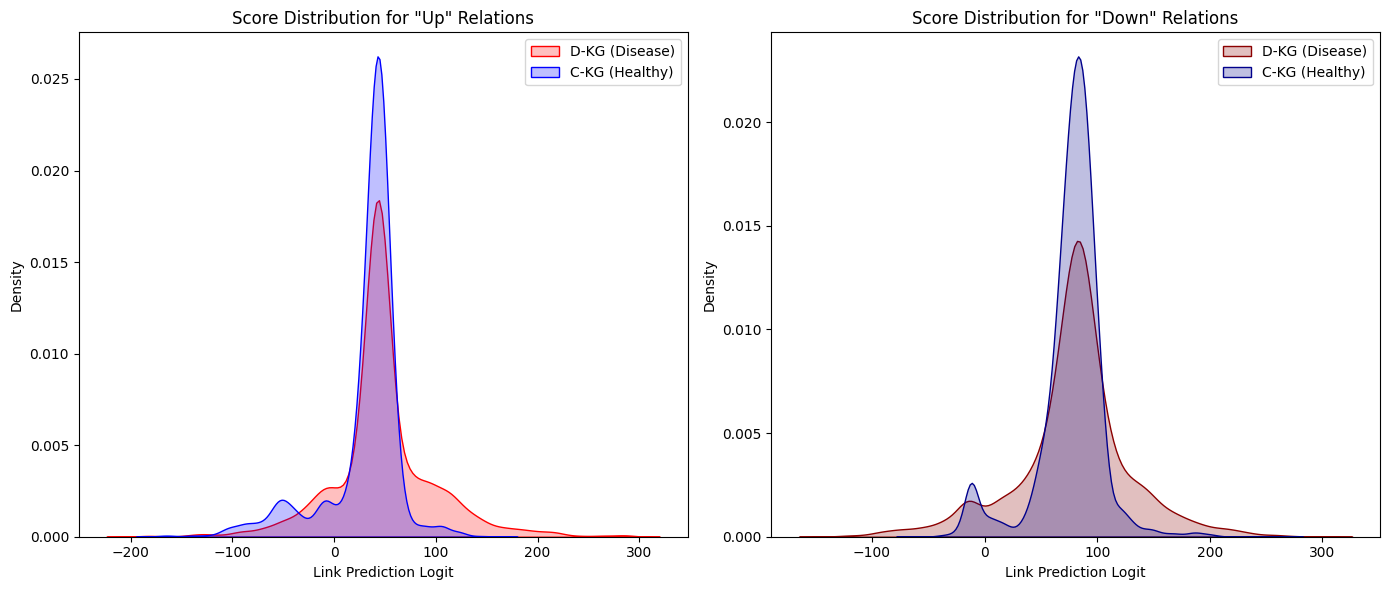

Plot saved to score_distributions.png


<Figure size 640x480 with 0 Axes>

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_score_distributions(d_scores_dict, c_scores_dict, save_path='score_distributions.png'):
    """
    Aggregates scores from both dictionaries and plots their distributions.
    """
    # Helper to flatten scores from {sample: {rel: tensor}}
    def extract_all_scores(score_dict):
        all_up = []
        all_down = []
        for sample_id in score_dict:
            # Convert tensors to numpy arrays
            up_vals = score_dict[sample_id]['up'].detach().cpu().numpy()
            down_vals = score_dict[sample_id]['down'].detach().cpu().numpy()
            all_up.extend(up_vals)
            all_down.extend(down_vals)
        return np.array(all_up), np.array(all_down)

    d_up, d_down = extract_all_scores(d_scores_dict)
    c_up, c_down = extract_all_scores(c_scores_dict)

    # Setup the figure with two subplots (one for 'up', one for 'down')
    plt.figure(figsize=(14, 6))

    # --- Plot 'Up' Distribution ---
    plt.subplot(1, 2, 1)
    sns.kdeplot(d_up, label='D-KG (Disease)', fill=True, color='red')
    sns.kdeplot(c_up, label='C-KG (Healthy)', fill=True, color='blue')
    plt.title('Score Distribution for "Up" Relations')
    plt.xlabel('Link Prediction Logit')
    plt.ylabel('Density')
    plt.legend()

    # --- Plot 'Down' Distribution ---
    plt.subplot(1, 2, 2)
    sns.kdeplot(d_down, label='D-KG (Disease)', fill=True, color='darkred')
    sns.kdeplot(c_down, label='C-KG (Healthy)', fill=True, color='darkblue')
    plt.title('Score Distribution for "Down" Relations')
    plt.xlabel('Link Prediction Logit')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.savefig(save_path)
    print(f"Plot saved to {save_path}")


plot_score_distributions(d_scores_dict, c_scores_dict)

### Edge Assignment

In [10]:
d_ids = {}
c_ids = {}
for k in d_up_ids.keys():
    d_ids[k] = {}
    d_ids[k]['up'] = d_up_ids[k]
    d_ids[k]['down'] = d_down_ids[k]
for k in c_up_ids.keys():
    c_ids[k] = {}
    c_ids[k]['up'] = c_up_ids[k]
    c_ids[k]['down'] = c_down_ids[k]


In [47]:
def get_top_k_assignments(d_scores_dict, c_scores_dict, d_ids, c_ids):
    """
    Ranks proteins based on combined scores from two dictionaries and returns assignments.
    """
    assignments = {}
        
    # Iterate through each sample_node_id
    for sample_id in d_scores_dict.keys():
        assignments[sample_id] = {}
        
        # Process 'up' and 'down' relations
        for relation in ['up', 'down']:
            # 1. Map scores to their protein IDs
            # a dictionary of protein_id -> d_score/c_score
            protein_map = {}
            
            # Extract d_scores
            d_scores = d_scores_dict[sample_id][relation]
            # normalize d_scores
            d_scores = (d_scores - d_scores.mean())/(d_scores.std()+1e-6)

            d_indices = d_ids[sample_id][relation]
            for idx, prot_id in enumerate(d_indices):
                protein_map[prot_id] = [d_scores[idx].item(),'d']
                
            # Extract c_scores and update map
            c_scores = c_scores_dict[sample_id][relation]
            # normalize c_scores
            c_scores = (c_scores - c_scores.mean())/(c_scores.std()+1e-6)

            c_indices = c_ids[sample_id][relation]
            for idx, prot_id in enumerate(c_indices):
                if prot_id in protein_map:
                    print(f'protein node id {prot_id} exists in both kgs candidate protein list.')
                else:
                    protein_map[prot_id] = [c_scores[idx].item(),'c']
            # print(d_indices)
            # print(c_indices)
            # print(protein_map)
            # 2. Ranking:by triple score
            sorted_proteins = sorted(
                protein_map.items(), 
                key=lambda item: (item[1][0]), 
                reverse=True
            )
            #print('sorted proteins:\n',sorted_proteins)
            # 3. Slice the Top K
            k = min(len(d_indices), len(c_indices))
            top_k = sorted_proteins[:k]
            #print('topk (sample-relation-protein) scores\n', top_k)
        #break
            # Prepare output tensors
            top_ids = torch.tensor([item[0] for item in top_k])
            top_scores = [item[1] for item in top_k] # [score, d/c] pairs
            
            assignments[sample_id][relation] = {
                'protein_ids': top_ids,
                'scores': top_scores
            }
    return assignments

assignent correction

In [96]:
nhs_dict = {v:nhs_scores[k] for k,v in node_mappings['Patient'].items()}

In [103]:
def get_neighbor_guided_top_k(d_scores_dict, c_scores_dict, d_ids, c_ids, nas_dict, alpha=2.0):
    assignments = {}
    
    for sample_id in d_scores_dict.keys():
        assignments[sample_id] = {}
        # Retrieve the Neighborhood Homophily Score for this sample
        # 1.0 = purely Disease neighbors, 0.0 = purely Healthy neighbors
        nas = nas_dict.get(sample_id, 0.5) 
        # Calculate the "Steering Bias"
        # If nas=1 (AD neighborhood), bias is +alpha for AD, -alpha for Healthy
        # If nas=0 (Healthy neighborhood), bias is -alpha for AD, +alpha for Healthy
        steering_bias = (nas - 0.5) * 2.0 * alpha
        print(f"Sample {sample_id} | NAS: {nas:.2f} | Bias: {steering_bias:.2f}")
        
        for relation in ['up', 'down']:
            protein_map = {}
            
            # calculate normalized and steering_bias additive scores
            d_scores_raw = d_scores_dict[sample_id][relation] 
            d_scores_norm = (d_scores_raw - d_scores_raw.mean())/(d_scores_raw.std()+1e-6)
            d_scores = d_scores_norm + steering_bias
            
            c_scores_raw = c_scores_dict[sample_id][relation] 
            c_scores_norm = (c_scores_raw - c_scores_raw.mean())/(c_scores_raw.std()+1e-6)
            c_scores = c_scores_norm - steering_bias
            print(f"Sample {sample_id} | d_score_norm\n: {d_scores_norm} | \nc_score_norm\n: {c_scores_norm}")
            print(f"Sample {sample_id} | d_score\n: {d_scores} | \nc_score\n: {c_scores}")
            # map and rank
            d_indices = d_ids[sample_id][relation]
            for idx, prot_id in enumerate(d_indices):
                protein_map[prot_id] = [d_scores[idx].item(), 'd']
                
            c_indices = c_ids[sample_id][relation]
            for idx, prot_id in enumerate(c_indices):
                if prot_id in protein_map:
                    print(f'protein node id {prot_id} exists in both kgs candidate protein list.')
                else:
                    protein_map[prot_id] = [c_scores[idx].item(),'c']
         
            # Ranking:by triple score
            sorted_proteins = sorted(
                protein_map.items(), 
                key=lambda item: (item[1][0]), 
                reverse=True
            )
            #print('sorted proteins:\n',sorted_proteins)
            # 3. Slice the Top K
            k = min(len(d_indices), len(c_indices))
            top_k = sorted_proteins[:k]
         
            # Prepare output tensors
            top_ids = torch.tensor([item[0] for item in top_k])
            top_scores = [item[1] for item in top_k] # [score, d/c] pairs
            
            assignments[sample_id][relation] = {
                'protein_ids': top_ids,
                'scores': top_scores,
                'nhs_score':nas
            }
    return assignments

In [104]:
corrected_assignments = get_neighbor_guided_top_k(d_scores_dict,
                                                  c_scores_dict,
                                                  d_ids,
                                                  c_ids,
                                                  nhs_dict,
                                                  2.0)

Sample 0 | NAS: 0.67 | Bias: 0.67
Sample 0 | d_score_norm
: tensor([ 0.5751, -0.3411,  2.4676, -0.2940,  1.2051, -0.2914,  1.3876,  1.1579,
         1.6337, -0.1196, -1.5909, -0.0945, -0.2637, -0.4522, -1.2330, -0.5408,
        -1.1869, -0.4045, -0.2502, -0.5321, -0.4120, -0.4201]) | 
c_score_norm
: tensor([-2.5172, -0.1027, -0.5361,  0.1268, -0.1600,  1.2592,  0.3386, -0.1471,
        -0.4845,  0.0774,  0.1536,  0.5988, -2.7366,  0.1819,  0.4693,  0.1024,
         0.1852,  1.1742,  0.2037,  0.4074, -0.1965,  1.6022])
Sample 0 | d_score
: tensor([ 1.2430,  0.3267,  3.1355,  0.3738,  1.8729,  0.3765,  2.0554,  1.8258,
         2.3015,  0.5483, -0.9230,  0.5734,  0.4041,  0.2157, -0.5652,  0.1271,
        -0.5191,  0.2634,  0.4176,  0.1358,  0.2559,  0.2477]) | 
c_score
: tensor([-3.1851, -0.7705, -1.2039, -0.5411, -0.8279,  0.5913, -0.3293, -0.8150,
        -1.1523, -0.5905, -0.5143, -0.0691, -3.4045, -0.4859, -0.1985, -0.5654,
        -0.4827,  0.5064, -0.4641, -0.2604, -0.8643,  0.934

In [17]:
isolated_proteins_ids = []
for k,v in node_mappings['Protein'].items():
    
    if not k.startswith('p('):
        #print(k,v)
        isolated_proteins_ids.append(v)

In [105]:
def update_heterodata(data, assignments, isolated_protein_ids):
    """
    1. Updates HeteroData inplace (edges only) & filter out edges involing isolated proteins
    2. Returns a list of dicts containing (sample_id, protein_id, relation, score, source).
    """
    isolated_set = set(isolated_protein_ids)
    edge_logs = []
    
    for sample_id, relations in assignments.items():
        for relation_type, content in relations.items():
            assigned_ids = content['protein_ids'] 
            raw_scores = content['scores']        # List of [score, 'd'/'c']
            nhs_score = content['nhs_score']
            
            # --- 1. Filter and Log Logic ---
            valid_indices = []
            for i, prot_id in enumerate(assigned_ids):
                p_id = prot_id.item()
                if p_id not in isolated_set:
                    valid_indices.append(i)
                    # save edge_log infos
                    edge_logs.append({
                        'sample_id': int(sample_id),
                        'protein_id': int(p_id),
                        'relation': relation_type,
                        'score': raw_scores[i][0],
                        'source_kg': raw_scores[i][1],
                        'nhs_score':nhs_score,
                        'label': data['Patient'].y[sample_id].item()
                    })
            
            if not valid_indices:
                continue
                
            filtered_ids = assigned_ids[valid_indices].long()
            num_new_edges = filtered_ids.size(0)
            
            # Prepare edge tensors
            src = torch.full((num_new_edges,), sample_id, dtype=torch.long)
            dst = filtered_ids

            # Define edge types
            fwd_etype = ('Patient', f'{relation_type}_reg', 'Protein')
            rev_etype = ('Protein', f'rev_{relation_type}_reg', 'Patient')

            # --- 2. Update HeteroData (Inplace) ---
            # Forward Update
            new_fwd = torch.stack([src, dst], dim=0)
            if fwd_etype in data.edge_types:
                data[fwd_etype].edge_index = torch.cat([data[fwd_etype].edge_index, new_fwd], dim=1)
            else:
                data[fwd_etype].edge_index = new_fwd

            # Reverse Update
            new_rev = torch.stack([dst, src], dim=0)
            if rev_etype in data.edge_types:
                data[rev_etype].edge_index = torch.cat([data[rev_etype].edge_index, new_rev], dim=1)
            else:
                data[rev_etype].edge_index = new_rev

    return data, edge_logs

In [112]:
def calculate_source_ratio(df):
    results = []
    
    # Grouping by sample_id
    grouped = df.groupby('sample_id')
    
    for sample_id, group in grouped:
        num_c = (group['source_kg'] == 'c').sum()
        num_d = (group['source_kg'] == 'd').sum()
        
        
        # Calculate ratio (c / d)
        ratio = num_c / num_d if num_d > 0 else float('inf')
        
        results.append({
            'sample_id': sample_id,
            'c_count': num_c,
            'd_count': num_d,
            'c_d_ratio': ratio,
            'nhs_score':group['nhs_score'].mean(),
            'label': group['label'].iloc[0] # To verify alignment with original label
        })
    
    return pd.DataFrame(results)

In [114]:
# corrected_assignments = get_neighbor_guided_top_k(d_scores_dict,
#                                                   c_scores_dict,
#                                                   d_ids,
#                                                   c_ids,
#                                                   nhs_scores,
#                                                   2.0)
data_corrective, corrected_edge_logs = update_heterodata(data, corrected_assignments, isolated_proteins_ids)

df_updated_edegs = pd.DataFrame(corrected_edge_logs)
df_edge_corrected = calculate_source_ratio(df_updated_edegs)
df_edge_corrected

,sample_id,c_count,d_count,c_d_ratio,nhs_score,label
0,0,9,52,0.173077,0.666962,0
1,2,7,8,0.875000,0.334797,1
2,3,2,24,0.083333,0.664808,0
3,7,6,21,0.285714,0.500676,1
4,8,16,34,0.470588,0.497963,0
...,...,...,...,...,...,...
132,445,16,39,0.410256,0.499978,1
133,447,5,64,0.078125,0.666508,1
134,451,12,38,0.315789,0.500000,1
135,452,6,58,0.103448,0.749225,1


In [94]:
df_edge_corrected[df_edge_corrected['label']==0]

,sample_id,c_count,d_count,c_d_ratio,label
0,0,9,52,0.173077,0
2,3,2,24,0.083333,0
4,8,16,34,0.470588,0
5,10,42,9,4.666667,0
6,11,15,37,0.405405,0
...,...,...,...,...,...
123,405,43,42,1.023810,0
125,420,2,58,0.034483,0
126,423,0,9,0.000000,0
128,425,4,28,0.142857,0


In [1]:
final_assignments = get_top_k_assignments(d_scores_dict,
                                                  c_scores_dict,
                                                  d_ids,
                                                  c_ids)

data_updated, added_edge_logs1 = update_heterodata(data, final_assignments, isolated_proteins_ids)

df_edges_1 = pd.DataFrame(added_edge_logs1)
df_edges_analysis1 = calculate_source_ratio(df_edges_1)
df_edges_analysis1.to_csv('assignment_analysis.csv')

NameError: name 'get_top_k_assignments' is not defined

In [81]:
final_assignments[0]

{'up': {'protein_ids': tensor([ 166,   70, 2260,   53, 1634,  628, 2357,  200, 2566,  138, 2521, 3034,
          3117, 3093, 2743, 3028, 3079, 2913, 2560, 3037,  306, 2508]),
  'scores': [[2.467608690261841, 'd'],
   [1.633653163909912, 'd'],
   [1.6022424697875977, 'c'],
   [1.3875532150268555, 'd'],
   [1.259151816368103, 'c'],
   [1.2050743103027344, 'd'],
   [1.174218773841858, 'c'],
   [1.157930850982666, 'd'],
   [0.5987836718559265, 'c'],
   [0.5751156806945801, 'd'],
   [0.46934986114501953, 'c'],
   [0.4074457585811615, 'c'],
   [0.3385753333568573, 'c'],
   [0.2037128359079361, 'c'],
   [0.18516650795936584, 'c'],
   [0.18191741406917572, 'c'],
   [0.15357844531536102, 'c'],
   [0.12675009667873383, 'c'],
   [0.10243412852287292, 'c'],
   [0.07737147808074951, 'c'],
   [-0.09447339177131653, 'd'],
   [-0.10265782475471497, 'c']]},
 'down': {'protein_ids': tensor([1923,   94,  281, 2188, 1150,  110, 2017,  902, 1014,  640, 2322,  720,
          1011, 2166,   45, 1946,  120,  4

In [85]:
corrected_assignments[0]

{'up': {'protein_ids': tensor([ 166,   70, 2260,   53, 1634,  628, 2357,  200, 2566,  138, 2521, 3034,
          3117, 3093, 2743, 3028, 3079, 2913, 2560, 3037,  306, 2508]),
  'scores': [[2.467608690261841, 'd'],
   [1.633653163909912, 'd'],
   [1.6022424697875977, 'c'],
   [1.3875532150268555, 'd'],
   [1.259151816368103, 'c'],
   [1.2050743103027344, 'd'],
   [1.174218773841858, 'c'],
   [1.157930850982666, 'd'],
   [0.5987836718559265, 'c'],
   [0.5751156806945801, 'd'],
   [0.46934986114501953, 'c'],
   [0.4074457585811615, 'c'],
   [0.3385753333568573, 'c'],
   [0.2037128359079361, 'c'],
   [0.18516650795936584, 'c'],
   [0.18191741406917572, 'c'],
   [0.15357844531536102, 'c'],
   [0.12675009667873383, 'c'],
   [0.10243412852287292, 'c'],
   [0.07737147808074951, 'c'],
   [-0.09447339177131653, 'd'],
   [-0.10265782475471497, 'c']]},
 'down': {'protein_ids': tensor([1923,   94,  281, 2188, 1150,  110, 2017,  902, 1014,  640, 2322,  720,
          1011, 2166,   45, 1946,  120,  4

## 7. Retrain

In [ ]:
 # --- STAGE 3: Retraining on Augmented Graph ---
print("--- Stage 3: Retraining ---")
# Refresh train_edges to include the new validation-protein connections
augmented_edges = {etype: data[etype].edge_index for etype in data.edge_types}

aug_train_edges, aug_val_edges, aug_test_edges = split_edges(
    augmented_edges,
    val_ratio=args.val_ratio,
    test_ratio=args.test_ratio,
    seed=args.seed
)

# We allow the model to backprop through the new structure
model, history = train(model, data, aug_train_edges, None, optimizer, device, epochs=args.epochs)

--- Stage 3: Retraining ---


Training HeteoGNN:  20%|██        | 1/5 [00:25<01:40, 25.24s/it]

Epoch 0 | {'loss': 15.043639183044434, 'cls_loss': 0.9167961478233337, 'link_loss': 28.253686904907227} | Val {'acc': 0.47058823529411764, 'f1_macro': 0.4306976744186047, 'auroc': 0.3532986111111111, 'auprc': 0.4371763604516474}


Training HeteoGNN:  40%|████      | 2/5 [00:42<01:01, 20.57s/it]

Epoch 1 | {'loss': 14.035066604614258, 'cls_loss': 0.9434292316436768, 'link_loss': 26.18327522277832} | Val {'acc': 0.4852941176470588, 'f1_macro': 0.44170771756978655, 'auroc': 0.5190972222222222, 'auprc': 0.618155503057592}


...

Epoch 2 | {'loss': 9.515098571777344, 'cls_loss': 0.8521494269371033, 'link_loss': 17.325899124145508} | Val {'acc': 0.5294117647058824, 'f1_macro': 0.34615384615384615, 'auroc': 0.6111111111111112, 'auprc': 0.6615797953641421}


Training HeteoGNN:  80%|████████  | 4/5 [01:18<00:18, 18.90s/it]

Epoch 3 | {'loss': 7.2883219718933105, 'cls_loss': 0.8506416082382202, 'link_loss': 12.875360488891602} | Val {'acc': 0.5588235294117647, 'f1_macro': 0.411764705882353, 'auroc': 0.6484375, 'auprc': 0.6357391111322044}


Training HeteoGNN: 100%|██████████| 5/5 [01:34<00:00, 18.93s/it]

Epoch 4 | {'loss': 5.747519493103027, 'cls_loss': 0.8693535923957825, 'link_loss': 9.756331443786621} | Val {'acc': 0.47058823529411764, 'f1_macro': 0.32, 'auroc': 0.5746527777777777, 'auprc': 0.5930719396734615}


In [ ]:
# 4. Test
print("\nTesting...\n")

test_cls_metrics, test_link_metrics = test(
    model,
    data,
    train_edges=train_edges,
    test_edges=test_edges,
    device=device
)

## Plot metrics

In [117]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Find all summary files across all experiments
files = glob.glob("../results/HybridLP/*/*/*/summary.csv")
df_metrics = pd.concat([pd.read_csv(f) for f in files])

In [103]:
df_metrics

,dataset,scoring,model,acc,f1_macro,auroc,auprc
0,geo,ecdf,gat,0.661972,0.646179,0.732270,0.855790
0,adni,ecdf,gat,0.507246,0.482804,0.513514,0.556631


In [107]:
df_melted = df_metrics.melt(
    id_vars=['dataset', 'scoring', 'model'], 
    value_vars=['acc', 'f1_macro', 'auroc', 'auprc'],
    var_name='Metric', 
    value_name='Score'
)
df_melted

,dataset,scoring,model,Metric,Score
0,geo,ecdf,gat,acc,0.661972
1,adni,ecdf,gat,acc,0.507246
2,geo,ecdf,gat,f1_macro,0.646179
3,adni,ecdf,gat,f1_macro,0.482804
4,geo,ecdf,gat,auroc,0.732270
5,adni,ecdf,gat,auroc,0.513514
6,geo,ecdf,gat,auprc,0.855790
7,adni,ecdf,gat,auprc,0.556631


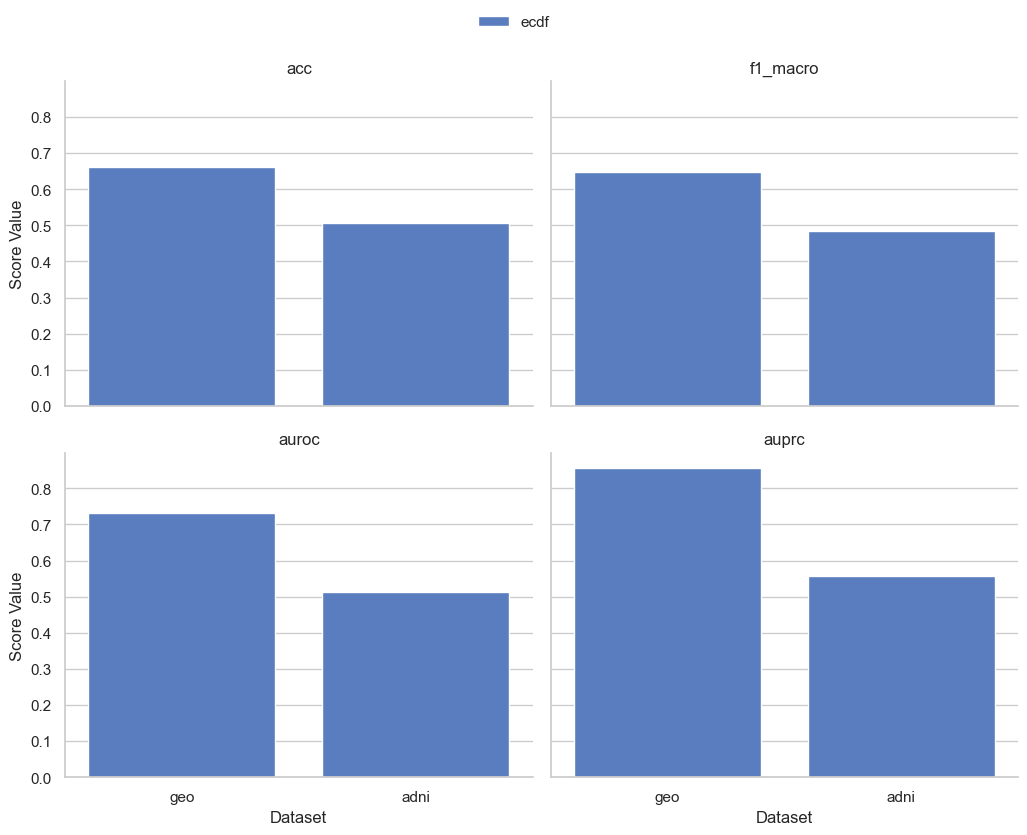

In [109]:
# plot
sns.set_theme(style="whitegrid")

# use catplot to create a "FacetGrid" (separate plots for each metric)
g = sns.catplot(
    data=df_melted, 
    kind="bar",
    x="dataset", 
    y="Score", 
    hue="scoring",
    col="Metric", 
    col_wrap=2,  # Arranges plots in a 2x2 grid
    palette="muted", 
    height=4, 
    aspect=1.2
)

g.set_axis_labels("Dataset", "Score Value")
g.set_titles("{col_name}")  # Titles for each subplot (acc, auroc, etc.)
#g.add_legend(title="Assignment Method")
sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300)
plt.show()

In [148]:
# Find all summary files across all experiments
def get_metrics(filedir="../results/HybridLP/*/*/*/*/summary.csv"):
    files = glob.glob(filedir)
    df_metrics = pd.concat([pd.read_csv(f) for f in files])
    df_melted = df_metrics.melt(
        id_vars=['dataset', 'scoring', 'model', 'modification'], 
        value_vars=['acc', 'f1_macro', 'auroc', 'auprc'],
        var_name='Metric', 
        value_name='Score'
    )
    
    return df_metrics, df_melted

In [146]:
def plot_metrics(df_melted):
    plt.figure(figsize=(16,20))
    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=df_melted, 
        kind="bar",
        x="dataset", 
        y="Score", 
        hue="modification",
        col="Metric", 
        col_wrap=2,
        palette="muted", 
        height=4, 
        aspect=1.2
    )

    g.set_axis_labels("Dataset", "Score Value")
    g.set_titles("{col_name}")

    # --- ADD LABELS HERE ---
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    # -----------------------

    sns.move_legend(
        g, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
    )

    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300)
    plt.show()

In [132]:
df_metrics, df_melted = get_metrics("../results/HybridLP/*/*/*/*/summary.csv")

In [139]:
df_metrics = df_metrics.fillna('unnormalized_triple_score')
df_metrics

,dataset,scoring,model,modification,acc,f1_macro,auroc,auprc
0,geo,ecdf,gat,nhs_corrective_assignment,0.901408,0.883251,0.901596,0.898038
0,geo,ecdf,gat,unnormalized_triple_score,0.661972,0.646179,0.732270,0.855790
0,geo,ecdf,gat,normalize_triple_score,0.774648,0.702306,0.820035,0.861268
0,adni,ecdf,gat,nhs_corrective_assignment,0.507246,0.494397,0.561655,0.633555
0,adni,ecdf,gat,unnormalized_triple_score,0.507246,0.482804,0.513514,0.556631
0,adni,ecdf,gat,normalize_triple_score,0.565217,0.553879,0.597128,0.599054


In [140]:
df_melted = df_melted.fillna('unnormalized_triple_score')

<Figure size 1600x2000 with 0 Axes>

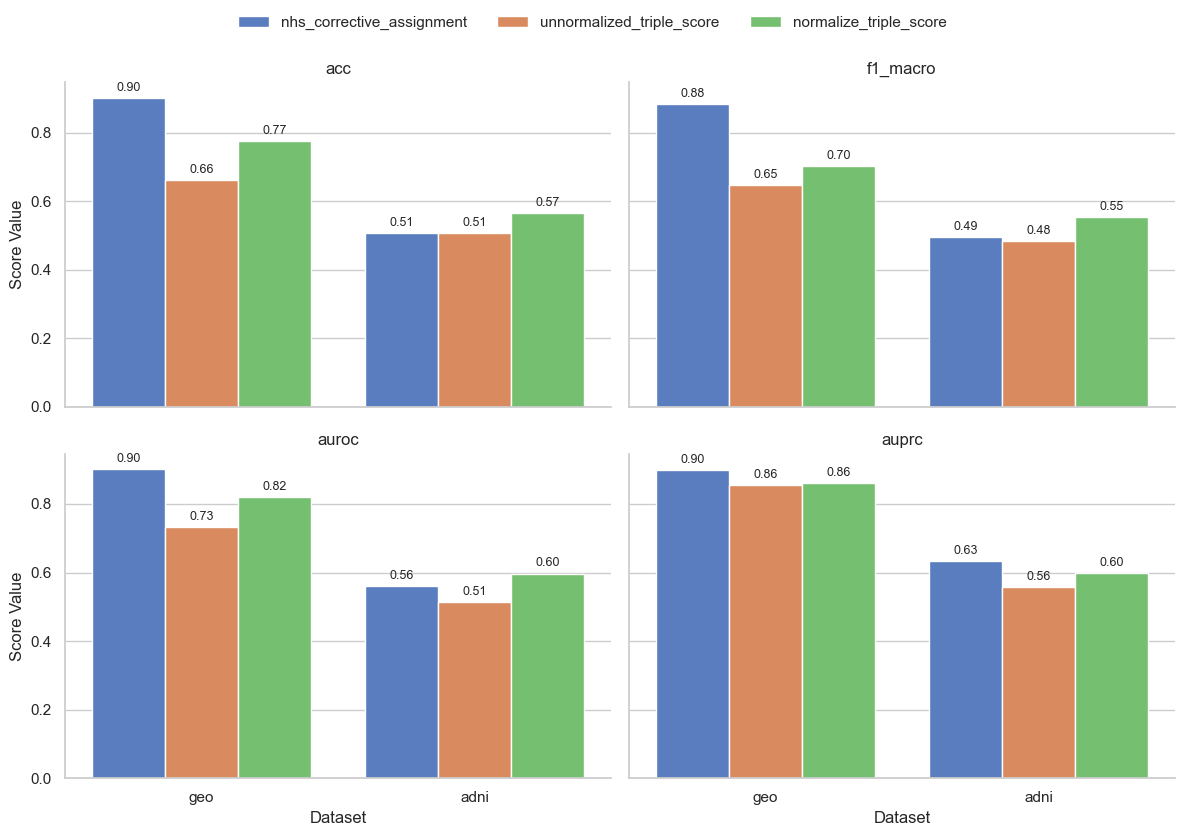

In [147]:
plot_metrics(df_melted)

## Edge Assignment Analysis

In [149]:
geo_assign = pd.read_csv("../results/HybridLP/geo/ecdf/gat/nhs_corrective_assignment/assignments_analysis.csv", index_col=0)
adni_assign = pd.read_csv("../results/HybridLP/adni/ecdf/gat/nhs_corrective_assignment/assignments_analysis.csv", index_col=0)

In [150]:
geo_assign

,sample_id,c_count,d_count,c_d_ratio,nhs_score,label
0,0,2,50,0.040000,1.000000,1
1,2,15,3,5.000000,0.000000,1
2,5,2,60,0.033333,1.000000,1
3,8,14,6,2.333333,0.249743,1
4,10,10,72,0.138889,0.668630,1
...,...,...,...,...,...,...
136,457,9,2,4.500000,0.200175,0
137,458,7,3,2.333333,0.124913,0
138,460,23,2,11.500000,0.000000,0
139,462,19,4,4.750000,0.000000,0


In [151]:
adni_assign

,sample_id,c_count,d_count,c_d_ratio,nhs_score,label
0,1,44,122,0.360656,0.501944,0
1,2,11,33,0.333333,0.601785,1
2,11,17,100,0.170000,0.667135,0
3,14,13,34,0.382353,0.499100,1
4,17,12,7,1.714286,0.336282,1
...,...,...,...,...,...,...
132,431,25,66,0.378788,0.500043,0
133,433,2,53,0.037736,1.000000,0
134,434,5,17,0.294118,0.500980,0
135,445,14,70,0.200000,0.666976,1
